<a href="https://colab.research.google.com/github/MHILAL-Dev2026/data-science-2026/blob/main/Pertemuan13_MuhammadHilalADM_250401020122.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PERTEMUAN 13 DATA SCIENCE

Nama : Muhammad Hilal AD

NIM : 250401020122

Kelas: IF 405

**Langkah 1: Generate & Eksplorasi Dataset Non-Linear**

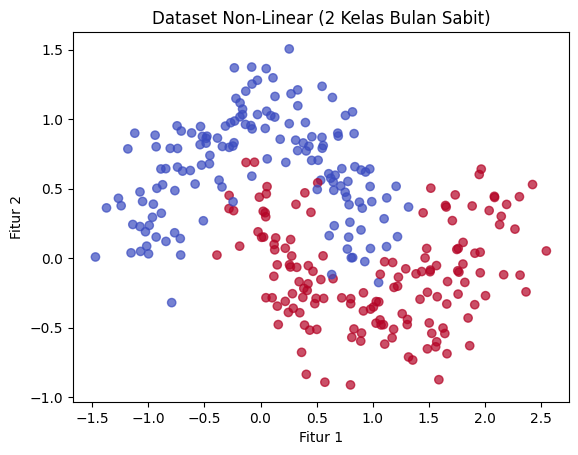

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Membuat dataset non-linear
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# Visualisasi dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.show()

**Langkah 2: Bangun & Latih Neural Network Sederhana**

In [3]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Pembagian data training dan testing
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# Membangun arsitektur Neural Network
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Kompilasi model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Menampilkan ringkasan arsitektur
model.summary()

# Melatih model
history = model.fit(X_tr, y_tr, epochs=30, validation_split=0.2, verbose=0)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

**Langkah 3: Evaluasi & Visualisasi Kurva Belajar**

Akurasi pada data uji: 0.883


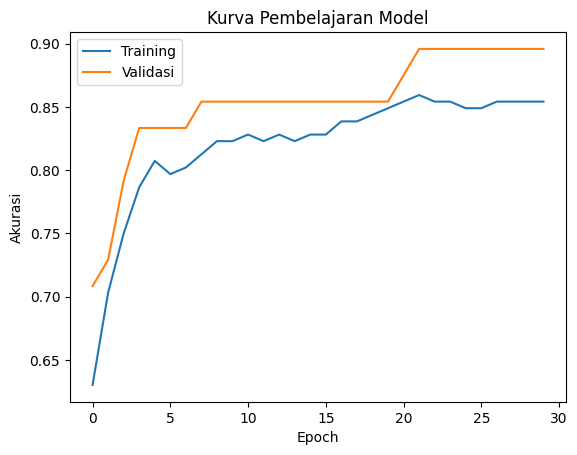

In [4]:
# Evaluasi model pada data uji
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

# Visualisasi kurva pembelajaran
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Kurva Pembelajaran Model')
plt.show()

Interpretasikan Apakah akurasi training & validasi saling mendekat (baik) atau saling menjauh (indikasi overfitting)?

Jawab: Akurasi training dan validasi saling mendekat serta stabil di nilai yang cukup tinggi serta tidak terlihat adanya indikasi overfitting yang signifikan. Jika terjadi overfitting, akurasi training akan terus naik mendekati 100% sementara akurasi validasi mengalami penurunan drastis. Fungsi aktivasi ReLU memungkinkan jaringan mempelajari batas non-linear dengan sangat baik.

**Langkah 4: Siapkan Dataset Ulasan Produk**

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Menyiapkan Dataset Ulasan (40 ulasan sampel)
ulasan = [
    'Barangnya bagus banget, pengiriman cepat',
    'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi',
    'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Pelayanan penjual sangat ramah dan merespon cepat',
    'Barang KW, jangan beli di toko ini',
    'Produk original dan berfungsi dengan baik',
    'Pengiriman lambat dan kemasan penyok',
    'Sangat bagus, respon penjual cepat',
    'Kualitas jelek dan kain tipis',
    'Mantap, barang sesuai dengan foto',
    'Kecewa berat, barang tidak lengkap',
    'Produk sangat memuaskan, mantap',
    'Sangat buruk, barang mati total',
    'Penjual ramah, barang ori',
    'Pengiriman sangat lama, mengecewakan',
    'Kualitas terbaik, recommended banget',
    'Rusak, tidak bisa digunakan',
    'Bagus sekali, packing aman dan rapi',
    'Penjual tidak ramah, respon lambat',
    'Sangat puas dengan kualitas barangnya',
    'Barang cacat dan tidak ramah',
    'Sesuai ekspektasi, sangat baik',
    'Pengiriman terlambat 3 hari, jelek',
    'Produk keren, pengiriman super cepat',
    'Tidak sesuai deskripsi, sangat rugi',
    'Pelayanan oke, produk mantap',
    'Kecewa, tidak sesuai dengan gambar',
    'Bagus, pengiriman cepat sekali',
    'Buruk, kualitas tidak sesuai harga',
    'Barang original, respon penjual cepat',
    'Penyok, tidak direkomendasikan',
    'Mantap jiwa, produk memuaskan',
    'Sangat lambat dan barang jelek',
    'Kualitas oke banget, packing rapi',
    'Rusak parah, penjual susah dihubungi',
    'Sangat recommended, respon mantap',
    'Jelek sekali, kapok beli di sini'
]

label = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0] # 1 = positif, 0 = negatif


**Langkah 5: Ubah Teks Menjadi TF-IDF**

In [8]:
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print('Daftar 10 kata pertama:', tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 77
Daftar 10 kata pertama: ['akan' 'aman' 'bagus' 'baik' 'banget' 'barang' 'barangnya' 'beli' 'berat'
 'berfungsi']


**Langkah 6: Latih Model Klasifikasi Sentimen & Evaluasi**

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Pembagian data teks
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42
)

# Pelatihan Logistic Regression
model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

# Evaluasi Akurasi
akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

# Pengujian dengan kalimat baru
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Hasil Prediksi:', 'Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.750
Hasil Prediksi: Positif


**Kesimpulan**

1. Pengolahan Data Non-Linear dengan Neural Network:


Dataset yang tidak bisa dipisahkan secara linier (seperti pola make_moons) dapat diklasifikasikan secara akurat oleh Neural Network berkat keberadaan fungsi aktivasi non-linear seperti ReLU pada hidden layer.

2. Representasi Teks dengan TF-IDF:

Metode TF-IDF berhasil mengubah dokumen teks (ulasan produk) menjadi matriks angka numerik yang memperhitungkan bobot kata unik.  

3. Penerapan Model Sentimen:

Model Logistic Regression yang dilatih menggunakan fitur TF-IDF mampu mengenali konteks kata-kata kunci (seperti "memuaskan" dan "ramah") untuk melakukan klasifikasi sentimen positif/negatif pada kalimat baru dengan tepat.  